# Лабораторна робота № 2 — зниження розмірності, кластеризація та класифікація текстів

Робота складається з трьох частин:

1. **Зниження розмірності** (PCA, t-SNE) на датасеті з лабораторної № 1 —
   Ethereum Fraud Detection.
2. **Кластерний аналіз** (K-Means) того самого датасета без використання
   міток.
3. **Класифікація текстів** — описи вразливостей із бази NVD, класифіковані
   за критичністю CVSS v3 (MEDIUM / HIGH / CRITICAL).

## 0. Підготовка середовища

Клітинка нижче створює теки `data/` та `assets/` і, якщо датасетів ще немає,
завантажує їх із Kaggle через `kagglehub`. У Colab вона також доставляє
відсутні пакети, тож ноутбук можна виконати там без жодних ручних кроків.

In [1]:
import importlib.util
import shutil
import subprocess
import sys
from pathlib import Path


def _in_colab():
    if "google.colab" in sys.modules:
        return True
    try:
        return importlib.util.find_spec("google.colab") is not None
    except (ImportError, ValueError):
        return False


IN_COLAB = _in_colab()

DATA = Path("data")
ASSETS = Path("assets")
DATA.mkdir(exist_ok=True)
ASSETS.mkdir(exist_ok=True)

ETH_PATH = DATA / "ethereum-fraud.csv"
ETH_SLUG = "vagifa/ethereum-frauddetection-dataset"
CVE_SLUG = "stanislavvinokur/cve-and-cwe-dataset-1999-2025"


def _ensure_packages():
    """У Colab більшість пакетів уже є; доставляємо лише те, чого бракує."""
    need = {"pandas": "pandas", "sklearn": "scikit-learn", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "wordcloud": "wordcloud", "kagglehub": "kagglehub"}
    missing = [pkg for mod, pkg in need.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("встановлюю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)


def _kaggle_csv(slug):
    """Завантажити набір із Kaggle (кешується) і повернути шлях до найбільшого CSV."""
    import kagglehub
    root = Path(kagglehub.dataset_download(slug))
    return max(root.rglob("*.csv"), key=lambda f: f.stat().st_size)


if IN_COLAB:
    _ensure_packages()

if not ETH_PATH.exists():
    print(f"завантажую {ETH_SLUG} ...")
    shutil.copy(_kaggle_csv(ETH_SLUG), ETH_PATH)
print(f"Ethereum: {ETH_PATH} ({ETH_PATH.stat().st_size / 1e6:.1f} МБ)")

# 103 МБ — у репозиторій не кладемо, читаємо прямо з кешу kagglehub
CVE_PATH = _kaggle_csv(CVE_SLUG)
print(f"CVE: {CVE_PATH.name} ({CVE_PATH.stat().st_size / 1e6:.1f} МБ)")

Ethereum: data/ethereum-fraud.csv (2.9 МБ)


CVE: CVE_CWE_2025.csv (102.9 МБ)


In [2]:
import re
import textwrap
import time

import matplotlib
# Agg потрібен лише коли код запускають як звичайний скрипт: без ядра Jupyter
# matplotlib шукав би GUI-бекенд. У ноутбуці лишаємо інлайн-бекенд.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             adjusted_rand_score, classification_report,
                             confusion_matrix, f1_score,
                             normalized_mutual_info_score, silhouette_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC
from wordcloud import WordCloud

RANDOM_STATE = 42
TEST_SIZE = 0.25

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"


def save(fig, name):
    """Зберегти рисунок в assets/ і показати його в ноутбуці."""
    fig.savefig(ASSETS / name)
    try:
        from IPython.display import display
        display(fig)
    except ImportError:
        pass
    plt.close(fig)
    print("збережено", ASSETS / name)


def short(name, width=32):
    return "\n".join(textwrap.wrap(name, width))

## 1. Зниження розмірності та візуалізація даних

### 1.1. Підготовка даних з лабораторної № 1

Дані готуються так само, як у лабораторній № 1: прибираються службові
колонки, через які протікала мітка (`Unnamed: 0`, `Index`, `Address`),
і константні колонки; пропуски заповнюються медіаною, категоріальні ознаки
кодуються one-hot з відсіканням рідкісних значень, числові стандартизуються.
Поділ на вибірки — той самий (75/25, стратифікований, `random_state = 42`),
тож результати порівнянні з лабораторною № 1.

In [3]:
TARGET = "FLAG"
eth = pd.read_csv(ETH_PATH)
eth.columns = [c.strip() for c in eth.columns]
eth = eth.drop(columns=["Unnamed: 0", "Index", "Address"])
_num = eth.drop(columns=[TARGET]).select_dtypes(include=[np.number])
eth = eth.drop(columns=[c for c in _num.columns if _num[c].nunique(dropna=True) <= 1])

NUM_COLS = eth.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
CAT_COLS = eth.drop(columns=[TARGET]).select_dtypes(exclude=[np.number]).columns.tolist()

X = eth.drop(columns=[TARGET])
y = eth[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)


def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), NUM_COLS),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                max_categories=11, sparse_output=False))]),
         CAT_COLS),
    ])


pre = make_preprocessor().fit(X_train)
Z_train = pre.transform(X_train)
N_FEATURES = Z_train.shape[1]
print(f"Акаунтів: {len(X)}; train {len(X_train)}, test {len(X_test)}")
print(f"Ознак після кодування: {N_FEATURES} ({len(NUM_COLS)} числових + one-hot)")

Акаунтів: 9841; train 7380, test 2461
Ознак після кодування: 60 (38 числових + one-hot)


### 1.2. Пояснена дисперсія

  80% дисперсії: 15 компонент із 60
  90% дисперсії: 20 компонент із 60
  95% дисперсії: 24 компонент із 60
  99% дисперсії: 32 компонент із 60
  перша компонента: 12.8%, перші дві: 23.0%


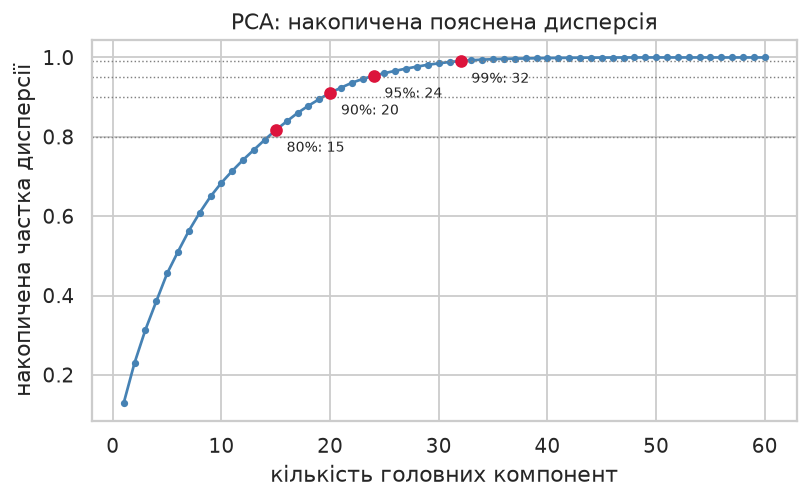

збережено assets/01-pca-variance.png


In [4]:
pca_full = PCA(random_state=RANDOM_STATE).fit(Z_train)
cum = np.cumsum(pca_full.explained_variance_ratio_)
N_FOR = {t: int(np.searchsorted(cum, t) + 1) for t in (0.80, 0.90, 0.95, 0.99)}
for t, n in N_FOR.items():
    print(f"  {t:.0%} дисперсії: {n:>2} компонент із {N_FEATURES}")
print(f"  перша компонента: {pca_full.explained_variance_ratio_[0]:.1%}, "
      f"перші дві: {cum[1]:.1%}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(range(1, len(cum) + 1), cum, marker=".", color="steelblue")
for t, n in N_FOR.items():
    ax.axhline(t, ls=":", color="grey", lw=.8)
    ax.plot(n, cum[n - 1], "o", color="crimson")
    ax.annotate(f"{t:.0%}: {n}", (n, cum[n - 1]), textcoords="offset points",
                xytext=(6, -12), fontsize=8)
ax.set_xlabel("кількість головних компонент")
ax.set_ylabel("накопичена частка дисперсії")
ax.set_title("PCA: накопичена пояснена дисперсія")
save(fig, "01-pca-variance.png")

Дисперсія розподілена по багатьох напрямках: перша компонента пояснює лише
12.8 %, перші дві — 23.0 %. Щоб зберегти 95 % дисперсії, потрібно 24 компоненти
з 60, а для 99 % — 32. Тобто PCA тут стискає ознаки приблизно **вдвічі**, а не
на порядок: між ознаками мало лінійної надлишковості (що узгоджується зі
слабкими кореляціями з лабораторної № 1).

### 1.3. Класифікація «до» та «після» PCA

Для порівняння взято SVM із RBF-ядром з параметрами, підібраними в
лабораторній № 1 (`C = 1000`, `gamma = 0.001`): він працює з відстанями, тож
саме на ньому ефект PCA найпоказовіший. Для контрасту та сама процедура
повторена для Random Forest. PCA стоїть **усередині pipeline** після
стандартизації, тобто компоненти рахуються лише на навчальній вибірці.

Час навчання вимірюється як медіана кількох повторів — одиничний замір на
частках секунди надто шумний.

In [5]:
def make_model(kind):
    if kind == "SVM":
        return SVC(kernel="rbf", C=1000, gamma=0.001, random_state=RANDOM_STATE)
    return RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)


def timed_fit(pipe, repeats):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        pipe.fit(X_train, y_train)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


variants = [("без PCA", None)] + [(f"PCA {n} комп.", n) for n in
                                  sorted({2, 5, 10, *N_FOR.values()})]
pca_rows = []
for kind, reps in (("SVM", 5), ("Random Forest", 3)):
    for label, n in variants:
        steps = [("pre", make_preprocessor())]
        if n:
            steps.append(("pca", PCA(n_components=n, random_state=RANDOM_STATE)))
        steps.append(("model", make_model(kind)))
        pipe = Pipeline(steps)
        fit_s = timed_fit(pipe, reps)
        pred = pipe.predict(X_test)
        pca_rows.append({"модель": kind, "варіант": label,
                         "ознак": n or N_FEATURES,
                         "дисперсії": cum[n - 1] if n else 1.0,
                         "accuracy": accuracy_score(y_test, pred),
                         "f1_macro": f1_score(y_test, pred, average="macro"),
                         "час навчання, с": fit_s})
        print(f"  {kind:<14} {label:<14} f1={pca_rows[-1]['f1_macro']:.4f}  {fit_s:.3f} с")

pca_res = pd.DataFrame(pca_rows)
pca_res.round(4).to_csv(DATA / "pca-comparison.csv", index=False)
print()
print(pca_res.round(4).to_string(index=False))

  SVM            без PCA        f1=0.9815  0.237 с


  SVM            PCA 2 комп.    f1=0.4377  1.642 с


  SVM            PCA 5 комп.    f1=0.4376  2.365 с


  SVM            PCA 10 комп.   f1=0.8675  1.245 с


  SVM            PCA 15 комп.   f1=0.8983  0.804 с


...

  Random Forest  PCA 10 комп.   f1=0.9514  0.750 с


  Random Forest  PCA 15 комп.   f1=0.9443  0.783 с


  Random Forest  PCA 20 комп.   f1=0.9492  0.892 с


  Random Forest  PCA 24 комп.   f1=0.9590  0.824 с


  Random Forest  PCA 32 комп.   f1=0.9791  0.960 с

       модель      варіант  ознак  дисперсії  accuracy  f1_macro  час навчання, с
          SVM      без PCA     60     1.0000    0.9874    0.9815           0.2367
          SVM  PCA 2 комп.      2     0.2299    0.7785    0.4377           1.6421
          SVM  PCA 5 комп.      5     0.4556    0.7781    0.4376           2.3648
          SVM PCA 10 комп.     10     0.6843    0.9155    0.8675           1.2453
          SVM PCA 15 комп.     15     0.8172    0.9313    0.8983           0.8036
          SVM PCA 20 комп.     20     0.9109    0.9354    0.9061           0.7215
          SVM PCA 24 комп.     24     0.9537    0.9395    0.9120           0.6346
          SVM PCA 32 комп.     32     0.9910    0.9691    0.9543           0.3738
Random Forest      без PCA     60     1.0000    0.9919    0.9881           0.6174
Random Forest  PCA 2 комп.      2     0.2299    0.9399    0.9107           0.6449
Random Forest  PCA 5 комп.      5     0.4556  

Параметри SVM (`C = 1000`, `gamma = 0.001`) підбирались для 60-вимірного
простору. Після PCA відстані між точками інші, тож ці параметри вже можуть
не підходити. Щоб відокремити вплив самого PCA від невдалих
гіперпараметрів, для кожного варіанта SVM підібрано наново тим самим
`GridSearchCV`, що й у лабораторній № 1.

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

grid = {"model__C": [1, 10, 100, 1000], "model__gamma": [0.001, 0.01, 0.1, 1]}
cv3 = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
tuned_rows = []
for label, n in variants:
    steps = [("pre", make_preprocessor())]
    if n:
        steps.append(("pca", PCA(n_components=n, random_state=RANDOM_STATE)))
    steps.append(("model", SVC(kernel="rbf", random_state=RANDOM_STATE)))
    gs = GridSearchCV(Pipeline(steps), grid, cv=cv3, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    fit_s = timed_fit(best, 5)
    pred = best.predict(X_test)
    fixed = pca_res[(pca_res["модель"] == "SVM") & (pca_res["варіант"] == label)].iloc[0]
    fixed_sv = Pipeline([s_ for s_ in best.steps[:-1]] +
                        [("model", make_model("SVM"))]).fit(X_train, y_train)
    tuned_rows.append({"варіант": label, "ознак": n or N_FEATURES,
                       "f1 (C=1000, γ=0.001)": fixed["f1_macro"],
                       "опорних векторів (фікс.)": int(fixed_sv[-1].n_support_.sum()),
                       "C": best[-1].C, "gamma": best[-1].gamma,
                       "f1 (підібрані)": f1_score(y_test, pred, average="macro"),
                       "опорних векторів (підібр.)": int(best[-1].n_support_.sum()),
                       "час, с (підібр.)": fit_s})
    print(f"  {label:<14} C={best[-1].C:<5} gamma={best[-1].gamma:<6} "
          f"f1={tuned_rows[-1]['f1 (підібрані)']:.4f}  {fit_s:.3f} с")
svm_tuned = pd.DataFrame(tuned_rows)
svm_tuned.round(4).to_csv(DATA / "pca-svm-tuned.csv", index=False)
print()
print(svm_tuned.round(4).to_string(index=False))

  без PCA        C=1000  gamma=0.1    f1=0.9810  0.258 с


  PCA 2 комп.    C=1000  gamma=1      f1=0.8774  2.024 с


  PCA 5 комп.    C=1000  gamma=1      f1=0.8868  1.225 с


  PCA 10 комп.   C=1000  gamma=1      f1=0.9426  0.926 с


  PCA 15 комп.   C=1000  gamma=1      f1=0.9539  0.711 с


  PCA 20 комп.   C=1000  gamma=0.1    f1=0.9601  0.648 с


  PCA 24 комп.   C=1000  gamma=0.1    f1=0.9619  0.504 с


  PCA 32 комп.   C=100   gamma=0.1    f1=0.9804  0.301 с

     варіант  ознак  f1 (C=1000, γ=0.001)  опорних векторів (фікс.)    C  gamma  f1 (підібрані)  опорних векторів (підібр.)  час, с (підібр.)
     без PCA     60                0.9815                       227 1000    0.1          0.9810                         371            0.2583
 PCA 2 комп.      2                0.4377                      3277 1000    1.0          0.8774                        1683            2.0240
 PCA 5 комп.      5                0.4376                      3285 1000    1.0          0.8868                        1342            1.2246
PCA 10 комп.     10                0.8675                      3182 1000    1.0          0.9426                         731            0.9260
PCA 15 комп.     15                0.8983                      1698 1000    1.0          0.9539                         520            0.7107
PCA 20 комп.     20                0.9061                      1398 1000    0.1          0

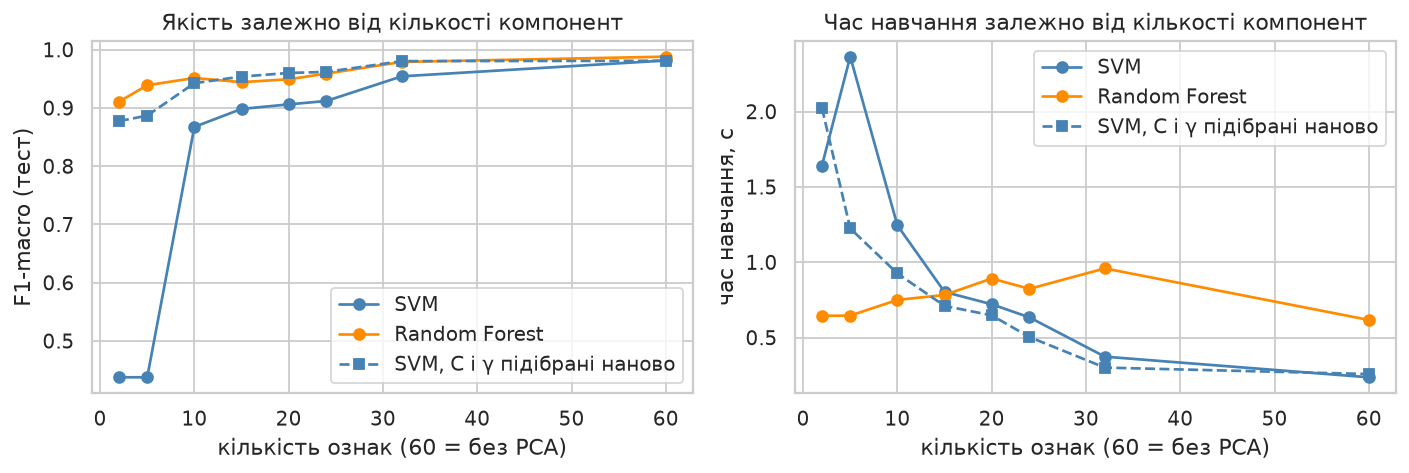

збережено assets/02-pca-comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for kind, color in (("SVM", "steelblue"), ("Random Forest", "darkorange")):
    d = pca_res[pca_res["модель"] == kind].sort_values("ознак")
    axes[0].plot(d["ознак"], d["f1_macro"], marker="o", color=color, label=kind)
    axes[1].plot(d["ознак"], d["час навчання, с"], marker="o", color=color, label=kind)
t_ = svm_tuned.sort_values("ознак")
axes[0].plot(t_["ознак"], t_["f1 (підібрані)"], ls="--", marker="s", color="steelblue",
             label="SVM, C і γ підібрані наново")
axes[1].plot(t_["ознак"], t_["час, с (підібр.)"], ls="--", marker="s", color="steelblue",
             label="SVM, C і γ підібрані наново")
axes[0].set_ylabel("F1-macro (тест)")
axes[1].set_ylabel("час навчання, с")
for ax in axes:
    ax.set_xlabel("кількість ознак (60 = без PCA)")
    ax.legend()
axes[0].set_title("Якість залежно від кількості компонент")
axes[1].set_title("Час навчання залежно від кількості компонент")
fig.tight_layout()
save(fig, "02-pca-comparison.png")

**Як PCA вплинув на якість.** З параметрами з лабораторної № 1 SVM після PCA
різко погіршується: на 2 і 5 компонентах F1 падає до 0.438 — рівно стільки,
скільки дає модель, що завжди відповідає «легітимний». Але це здебільшого
ефект **гіперпараметрів**, а не самого PCA. `gamma = 0.001` підібрано для
60-вимірного простору; після проєкції на кілька компонент відстані між точками
стають меншими, і таке широке ядро майже не розрізняє точок. Із заново
підібраними `C` і `gamma` той самий SVM на 2 компонентах дає вже 0.877, а на 32
компонентах (99 % дисперсії) — 0.980, тобто практично стільки ж, скільки без
PCA (0.981).

**Наскільки вдалося зменшити кількість ознак.** Без помітної втрати якості — з
60 до 32 (удвічі). Подальше стиснення коштує якості монотонно: 24 компоненти —
0.962, 10 — 0.943, 2 — 0.877.

**Чи змінився час навчання.** Всупереч очікуванню, PCA SVM **не прискорив**:
на 2 компонентах навчання навіть кілька разів повільніше, ніж на 60 ознаках.
Час навчання SVM визначається не розмірністю, а кількістю опорних векторів, а
вона тим більша, чим гірше розділені класи. Колапс на 2 компонентах дав 3 277
опорних векторів проти 227 без PCA — і саме це робить навчання повільнішим.

Random Forest реагує на PCA м'якше (0.911 уже на 2 компонентах), але теж
найкращий без нього (0.988) і теж не стає швидшим. Для дерев PCA ще й
незручний: головні компоненти — лінійні комбінації всіх ознак, тож прості
порогові правила на кшталт «час життя акаунта < N хвилин» стають похилими
межами, які деревам апроксимувати важче.

### 1.4. t-SNE: візуалізація у 2D

t-SNE будується на всіх 9 841 акаунтах після тієї самої підготовки. Мітки
класів у побудові не беруть участі — ними лише розфарбовано точки.

t-SNE: 22.1 с


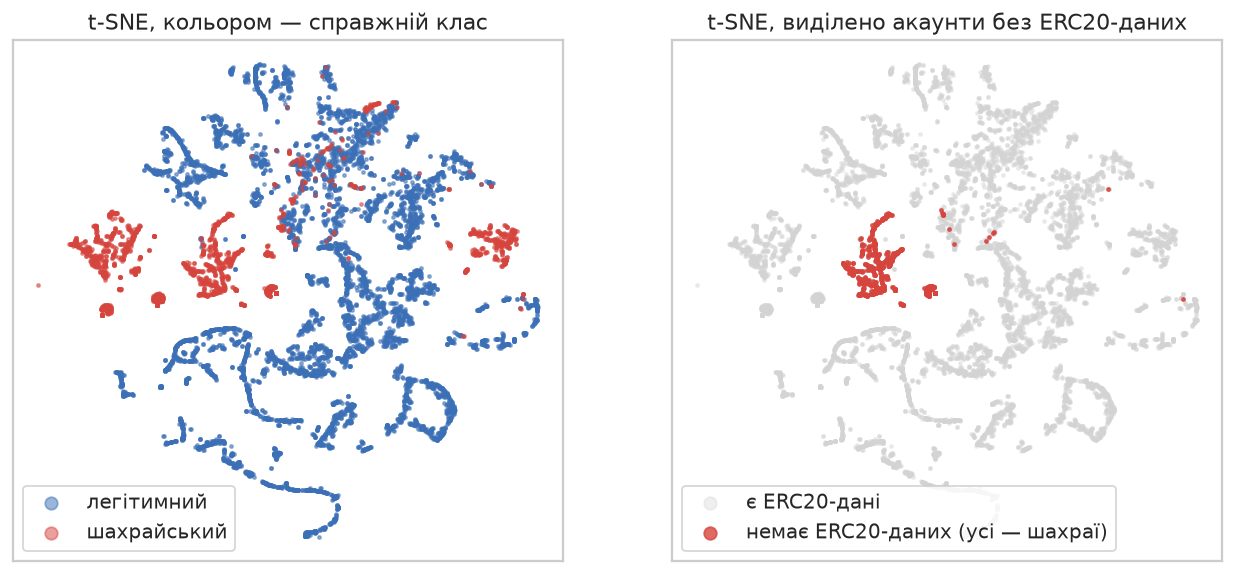

збережено assets/03-tsne.png


In [8]:
Z_all = pre.transform(X)
t0 = time.perf_counter()
tsne_xy = TSNE(n_components=2, perplexity=30, init="pca",
               random_state=RANDOM_STATE).fit_transform(Z_all)
print(f"t-SNE: {time.perf_counter() - t0:.1f} с")

no_erc = X["Total ERC20 tnxs"].isna().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for cls, color, name in ((0, "#3b6fb6", "легітимний"), (1, "#d6453d", "шахрайський")):
    m = (y == cls).to_numpy()
    axes[0].scatter(*tsne_xy[m].T, s=3, alpha=.5, color=color, label=name)
axes[0].set_title("t-SNE, кольором — справжній клас")
axes[0].legend(markerscale=4)
axes[1].scatter(*tsne_xy[~no_erc].T, s=3, alpha=.35, color="lightgrey", label="є ERC20-дані")
axes[1].scatter(*tsne_xy[no_erc].T, s=3, alpha=.8, color="#d6453d",
                label="немає ERC20-даних (усі — шахраї)")
axes[1].set_title("t-SNE, виділено акаунти без ERC20-даних")
axes[1].legend(markerscale=4)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
save(fig, "03-tsne.png")

На відміну від PCA, t-SNE розділяє класи візуально добре: шахрайські акаунти
утворюють кілька компактних «островів» (червоні скупчення ліворуч, праворуч і
в центрі), а легітимні — довгі ланцюжки. Частина шахраїв усе ж змішана з
легітимними у верхній частині карти — це ті випадки, які й лишаються помилками
класифікаторів.

Права панель показує, що один з островів — рівно ті 829 акаунтів без
ERC20-даних, знайдені в лабораторній № 1. t-SNE виокремив їх, нічого не знаючи
про мітки: після заповнення пропусків медіаною їхні ERC20-ознаки однакові, тож
вони буквально збігаються в цих вимірах. Решта островів — справжні групи з
подібною поведінкою.

Різниця з PCA принципова. PCA зберігає напрямки **найбільшої дисперсії**, а тут
вона створюється кількома акаунтами з екстремальними значеннями. t-SNE
зберігає **локальне сусідство**, тож важкі хвости йому не заважають. Водночас
відстані між островами на карті t-SNE не мають сенсу — метод їх не зберігає.

## 2. Кластерний аналіз (K-Means)

Кластеризація працює з тією самою підготовленою матрицею ознак, **без**
стовпця `FLAG`. Мітки використовуються лише після кластеризації — щоб
порівняти знайдені кластери зі справжніми класами.

### 2.1. K-Means на ознаках з лабораторної № 1

  k= 2  inertia=    393286  silhouette=0.979  розміри: [9839, 2]


  k= 3  inertia=    365224  silhouette=0.932  розміри: [9820, 19, 2]


  k= 4  inertia=    340412  silhouette=0.979  розміри: [9838, 1, 1, 1]


  k= 5  inertia=    309618  silhouette=0.851  розміри: [9666, 172, 1, 1, 1]


  k= 6  inertia=    288812  silhouette=0.861  розміри: [9657, 177, 3, 2, 1, 1]


  k= 7  inertia=    261068  silhouette=0.853  розміри: [9662, 172, 3, 1, 1, 1, 1]


  k= 8  inertia=    240283  silhouette=0.837  розміри: [9653, 168, 13, 3, 1, 1, 1, 1]


  k= 9  inertia=    227154  silhouette=0.836  розміри: [9651, 167, 15, 3, 1, 1, 1, 1, 1]


  k=10  inertia=    205317  silhouette=0.464  розміри: [7991, 1672, 156, 13, 3, 2, 1, 1, 1, 1]


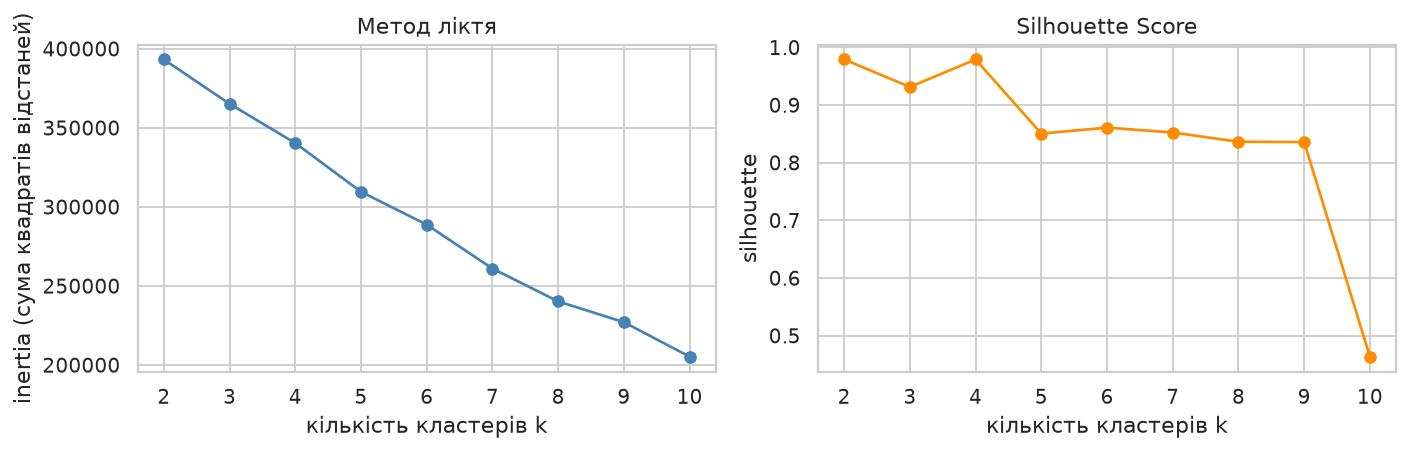

збережено assets/04-kmeans-k.png


In [9]:
K_RANGE = range(2, 11)
km_rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z_all)
    sil = silhouette_score(Z_all, km.labels_, sample_size=4000, random_state=RANDOM_STATE)
    sizes = np.bincount(km.labels_)
    km_rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil,
                    "найменший кластер": int(sizes.min()),
                    "найбільший кластер": int(sizes.max())})
    print(f"  k={k:>2}  inertia={km.inertia_:>10.0f}  silhouette={sil:.3f}  "
          f"розміри: {sorted(sizes.tolist(), reverse=True)}")
km_res = pd.DataFrame(km_rows)
km_res.round(4).to_csv(DATA / "kmeans-k.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(km_res["k"], km_res["inertia"], marker="o", color="steelblue")
axes[0].set_title("Метод ліктя")
axes[0].set_ylabel("inertia (сума квадратів відстаней)")
axes[1].plot(km_res["k"], km_res["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_ylabel("silhouette")
for ax in axes:
    ax.set_xlabel("кількість кластерів k")
fig.tight_layout()
save(fig, "04-kmeans-k.png")

In [10]:
BEST_K = int(km_res.loc[km_res["silhouette"].idxmax(), "k"])
print(f"k з найбільшим silhouette: {BEST_K}")

def cluster_vs_class(labels, title):
    ct = pd.crosstab(pd.Series(labels, name="кластер"), y.rename("клас"))
    ct["частка шахраїв"] = (ct[1] / ct.sum(axis=1)).round(3)
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    print(f"--- {title}: ARI = {ari:.3f}, NMI = {nmi:.3f}")
    print(ct.to_string())
    return ari, nmi

km_best = KMeans(n_clusters=BEST_K, n_init=10, random_state=RANDOM_STATE).fit(Z_all)
km2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(Z_all)
ari_best, nmi_best = cluster_vs_class(km_best.labels_, f"K-Means, k = {BEST_K}")
ari_2, nmi_2 = cluster_vs_class(km2.labels_, "K-Means, k = 2 (скільки класів)")

k з найбільшим silhouette: 2


--- K-Means, k = 2: ARI = -0.000, NMI = 0.000
клас        0     1  частка шахраїв
кластер                            
0        7660  2179           0.221
1           2     0           0.000
--- K-Means, k = 2 (скільки класів): ARI = -0.000, NMI = 0.000
клас        0     1  частка шахраїв
кластер                            
0        7660  2179           0.221
1           2     0           0.000


Результат вироджений, хоча silhouette виглядає блискуче (0.979 при k = 2).
K-Means просто відокремив **дві** точки від решти 9 839: після стандартизації
кілька акаунтів лежать за сотні стандартних відхилень від середнього
(максимальне |z| = 202), і K-Means, що мінімізує суму **квадратів** відстаней,
найдешевше «пояснює» дані, віддавши їм окремий кластер. Аж до k = 9 картина
однакова: один кластер із понад 9 600 акаунтів, а решта — від однієї точки до
кількох сотень.

Висока silhouette тут не ознака якості, а наслідок тих самих викидів: для
майже всіх точок найближчий «чужий» кластер — це кілька далеких викидів, тож
кожна точка здається ідеально віднесеною. ARI з класами = 0.000: така
кластеризація нічого не каже про шахрайство.

### 2.2. K-Means після логарифмування важкохвостих ознак

Числові ознаки тут — суми ETH, лічильники транзакцій, інтервали часу — мають
асиметрію до 58, тож після стандартизації кілька екстремальних акаунтів
лежать за десятки стандартних відхилень від решти. K-Means мінімізує суму
**квадратів** відстаней, тому такі точки й стають окремими кластерами.
Стандартний прийом для грошових і лічильних величин — перейти до
логарифмічної шкали: `sign(x)·log(1 + |x|)` (знак зберігаємо, бо баланс може
бути від'ємним). Після цього стандартизація працює з порядками величин, а не
з абсолютними значеннями.

Максимальне |z| після стандартизації: без логарифма 202, з логарифмом 89.0


  k= 2  inertia=   290651  silhouette=0.453  розміри: [8415, 1426]


  k= 3  inertia=   244958  silhouette=0.276  розміри: [6145, 2364, 1332]


  k= 4  inertia=   215525  silhouette=0.280  розміри: [6146, 2363, 1329, 3]


  k= 5  inertia=   193627  silhouette=0.246  розміри: [3740, 2702, 2221, 1175, 3]


  k= 6  inertia=   178022  silhouette=0.285  розміри: [2858, 2418, 2152, 1267, 1143, 3]


  k= 7  inertia=   164696  silhouette=0.286  розміри: [2299, 2107, 2065, 1313, 1271, 783, 3]


  k= 8  inertia=   150986  silhouette=0.294  розміри: [2320, 2108, 2060, 1317, 1247, 758, 28, 3]


  k= 9  inertia=   143326  silhouette=0.296  розміри: [2262, 2105, 2034, 1255, 1029, 718, 423, 13, 2]


  k=10  inertia=   136221  silhouette=0.301  розміри: [2091, 1819, 1454, 1426, 1209, 634, 596, 581, 28, 3]


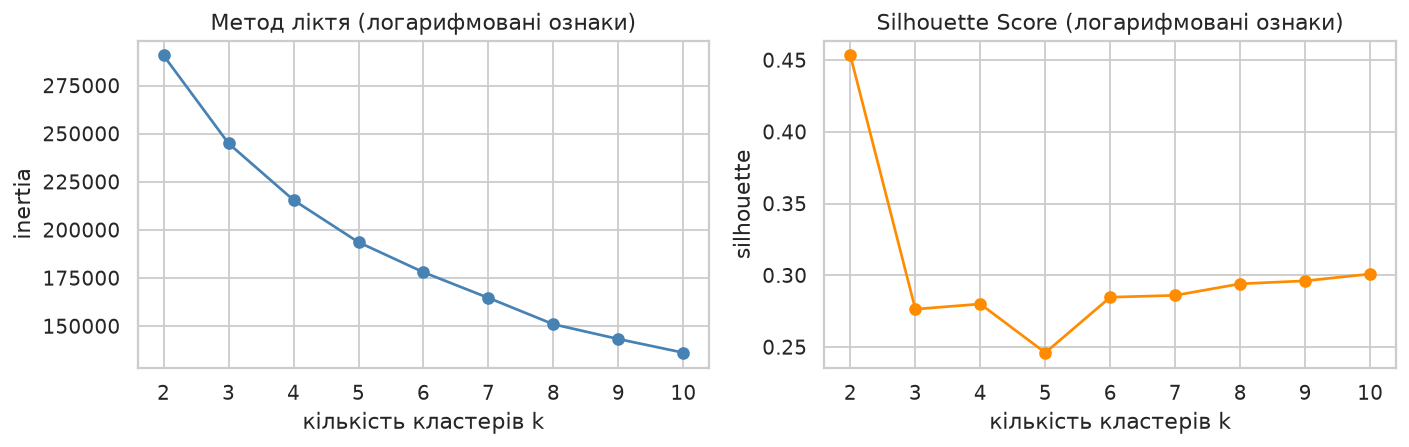

збережено assets/05-kmeans-k-log.png


In [11]:
from sklearn.preprocessing import FunctionTransformer


def signed_log1p(a):
    return np.sign(a) * np.log1p(np.abs(a))


def make_log_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("log", FunctionTransformer(signed_log1p)),
                          ("sc", StandardScaler())]), NUM_COLS),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                max_categories=11, sparse_output=False))]),
         CAT_COLS),
    ])


L_all = make_log_preprocessor().fit_transform(X)
print("Максимальне |z| після стандартизації: "
      f"без логарифма {np.abs(Z_all[:, :len(NUM_COLS)]).max():.0f}, "
      f"з логарифмом {np.abs(L_all[:, :len(NUM_COLS)]).max():.1f}")

log_rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(L_all)
    sil = silhouette_score(L_all, km.labels_, sample_size=4000, random_state=RANDOM_STATE)
    sizes = np.bincount(km.labels_)
    share = pd.Series(y.to_numpy()).groupby(km.labels_).agg(["mean", "size"])
    share = share[share["size"] >= 50]          # кластери з кількох точок не показові
    log_rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil,
                     "найменший кластер": int(sizes.min()),
                     "найбільший кластер": int(sizes.max()),
                     "ARI з класами": adjusted_rand_score(y, km.labels_),
                     "мін. частка шахраїв": share["mean"].min(),
                     "макс. частка шахраїв": share["mean"].max()})
    print(f"  k={k:>2}  inertia={km.inertia_:>9.0f}  silhouette={sil:.3f}  "
          f"розміри: {sorted(sizes.tolist(), reverse=True)}")
log_res = pd.DataFrame(log_rows)
log_res.round(4).to_csv(DATA / "kmeans-k-log.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(log_res["k"], log_res["inertia"], marker="o", color="steelblue")
axes[0].set_title("Метод ліктя (логарифмовані ознаки)")
axes[0].set_ylabel("inertia")
axes[1].plot(log_res["k"], log_res["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score (логарифмовані ознаки)")
axes[1].set_ylabel("silhouette")
for ax in axes:
    ax.set_xlabel("кількість кластерів k")
fig.tight_layout()
save(fig, "05-kmeans-k-log.png")

In [12]:
LOG_K = int(log_res.loc[log_res["silhouette"].idxmax(), "k"])
print(f"k з найбільшим silhouette: {LOG_K}")
km_log = KMeans(n_clusters=LOG_K, n_init=10, random_state=RANDOM_STATE).fit(L_all)
km_log2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(L_all)
ari_log, nmi_log = cluster_vs_class(km_log.labels_, f"K-Means на логарифмованих ознаках, k = {LOG_K}")
if LOG_K != 2:
    cluster_vs_class(km_log2.labels_, "K-Means на логарифмованих ознаках, k = 2")

k з найбільшим silhouette: 2


--- K-Means на логарифмованих ознаках, k = 2: ARI = -0.069, NMI = 0.025
клас        0     1  частка шахраїв
кластер                            
0        1312   114           0.080
1        6350  2065           0.245


In [13]:
print(log_res[["k", "silhouette", "ARI з класами", "мін. частка шахраїв",
               "макс. частка шахраїв"]].round(3).to_string(index=False))


def profile(labels):
    """Чим відрізняються кластери: розмір, частка шахраїв і типова поведінка."""
    g = pd.Series(labels, name="кластер")
    return pd.DataFrame({
        "акаунтів": g.value_counts().sort_index(),
        "частка шахраїв": pd.Series(y.to_numpy()).groupby(labels).mean(),
        "мають ERC20-активність": pd.Series((X["Total ERC20 tnxs"] > 0).to_numpy()).groupby(labels).mean(),
        "медіана надісланих tnx": X["Sent tnx"].groupby(labels).median(),
        "медіана отриманих tnx": X["Received Tnx"].groupby(labels).median(),
        "медіана «віку», днів": (X["Time Diff between first and last (Mins)"] / 1440).groupby(labels).median(),
    }).round(3)


SECOND_K = int(log_res[log_res["k"] != LOG_K].sort_values("silhouette").iloc[-1]["k"])
print(f"\nПрофіль кластерів, k = {LOG_K} (найкращий silhouette):")
print(profile(km_log.labels_).to_string())
km_second = KMeans(n_clusters=SECOND_K, n_init=10, random_state=RANDOM_STATE).fit(L_all)
print(f"\nПрофіль кластерів, k = {SECOND_K} (другий за silhouette):")
print(profile(km_second.labels_).to_string())

 k  silhouette  ARI з класами  мін. частка шахраїв  макс. частка шахраїв
 2       0.453         -0.069                0.080                 0.245
 3       0.276         -0.065                0.012                 0.333
 4       0.280         -0.065                0.012                 0.333
 5       0.246          0.037                0.010                 0.481
 6       0.285          0.028                0.010                 0.488
 7       0.286          0.033                0.008                 0.527
 8       0.294          0.033                0.008                 0.527
 9       0.296          0.031                0.008                 0.532
10       0.301          0.060                0.007                 0.648

Профіль кластерів, k = 2 (найкращий silhouette):
   акаунтів  частка шахраїв  мають ERC20-активність  медіана надісланих tnx  медіана отриманих tnx  медіана «віку», днів
0      1426           0.080                   1.000                    50.0                   29.0 


Профіль кластерів, k = 10 (другий за silhouette):
   акаунтів  частка шахраїв  мають ERC20-активність  медіана надісланих tnx  медіана отриманих tnx  медіана «віку», днів
0      1209           0.131                   0.787                     0.0                   69.0               157.466
1      2091           0.007                   0.007                     3.0                    2.0                 0.070
2      1819           0.501                   0.287                     1.0                    1.0                 0.010
3       634           0.084                   1.000                   100.5                   39.5               506.287
4      1426           0.648                   0.834                     3.0                    7.0                36.803
5       596           0.094                   1.000                    15.0                    9.0               230.011
6         3           0.000                   1.000                   146.0                   83.0    

Після логарифмування структура стає змістовною: silhouette знову найбільший
при k = 2 (0.453), але тепер кластери мають розміри 8 415 і 1 426, а не 9 839 і 2.

**Чи відповідають кластери класам?** Ні — ARI = −0.069, тобто розбиття навіть
трохи гірше за випадкове відносно міток. Профіль пояснює чому: K-Means поділив
акаунти за **рівнем активності**, а не за чесністю. Менший кластер — активні
довгоживучі акаунти (медіана 50 надісланих і 29 отриманих транзакцій, «вік»
понад рік, усі з ERC20-активністю), більший — малоактивні й короткоживучі
(2 і 3 транзакції, близько 10 днів). Шахраї є в обох, хоч і в різній пропорції
(8 % проти 24.5 %). Це закономірно: найсильніша структура в даних — те, як
активно користуються акаунтом, і вона не збігається з межею між класами.

При більшій кількості кластерів картина цікавіша. Уже з k = 5 з'являються
кластери, майже однорідні за класом (частка шахраїв від 1 % до 48 %), а при
k = 10 — від 0.7 % до 64.8 %. Наприклад, кластер 1 (2 091 акаунт, «вік» близько
1.7 години, по 2–3 транзакції) майже цілком легітимний, а кластер 2 (1 819
акаунтів, «вік» близько 15 хвилин, по одній транзакції) — наполовину
шахрайський. K-Means не відтворює класів, але знаходить **підгрупи з дуже
різним ризиком**, і саме в такій ролі він корисний для аналізу шахрайства.

Окрема деталь: у кластері 7 медіана отриманих транзакцій — рівно 9 999, а
максимум у всьому датасеті — рівно 10 000. Схоже, що збирач даних обрізав
історію акаунта на 10 000 транзакцій; тоді це ще один артефакт складання
датасета, а не властивість поведінки.

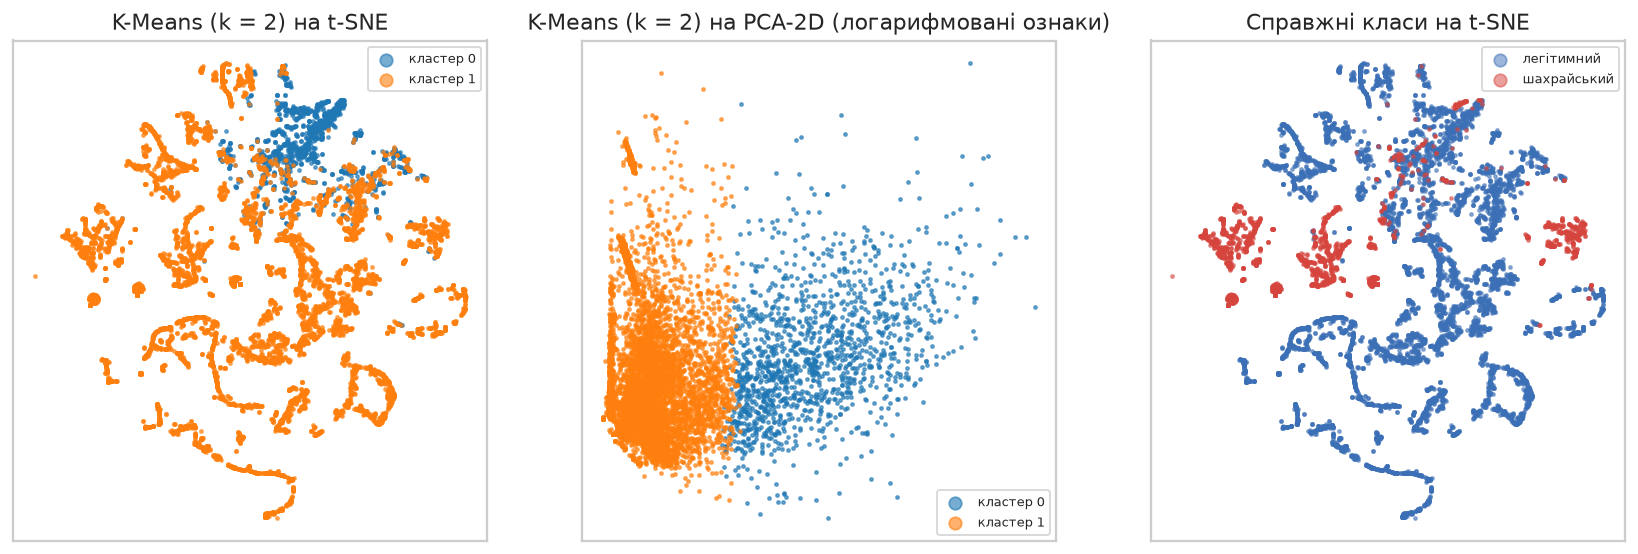

збережено assets/06-kmeans-clusters.png


In [14]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(L_all)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pal = sns.color_palette("tab10", LOG_K)
for c in range(LOG_K):
    m = km_log.labels_ == c
    axes[0].scatter(*tsne_xy[m].T, s=3, alpha=.6, color=pal[c], label=f"кластер {c}")
    axes[1].scatter(*pca2[m].T, s=3, alpha=.6, color=pal[c], label=f"кластер {c}")
for cls, color, name in ((0, "#3b6fb6", "легітимний"), (1, "#d6453d", "шахрайський")):
    m = (y == cls).to_numpy()
    axes[2].scatter(*tsne_xy[m].T, s=3, alpha=.5, color=color, label=name)
axes[0].set_title(f"K-Means (k = {LOG_K}) на t-SNE")
axes[1].set_title(f"K-Means (k = {LOG_K}) на PCA-2D (логарифмовані ознаки)")
axes[2].set_title("Справжні класи на t-SNE")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=4, fontsize=7)
save(fig, "06-kmeans-clusters.png")

На t-SNE видно, що кластери K-Means перетинають острови шахраїв, а не
обводять їх: розбиття йде за іншою віссю — інтенсивністю використання
акаунта.

## 3. Обробка та класифікація текстових даних

### 3.1. Датасет і його очищення

Описи вразливостей (CVE) із National Vulnerability Database, мітка —
критичність за CVSS v3.

In [15]:
cve_raw = pd.read_csv(CVE_PATH, low_memory=False)
steps = [("усього записів", len(cve_raw))]
for c in ("CVSS-V3", "CVSS-V2"):
    cve_raw[c] = pd.to_numeric(cve_raw[c], errors="coerce")
cve_raw["year"] = cve_raw["CVE-ID"].str.extract(r"CVE-(\d{4})")[0].astype(float)

print("Частка CRITICAL у колонці SEVERITY за періодами:")
print(cve_raw.groupby(pd.cut(cve_raw["year"], [1998, 2015, 2019, 2022, 2026]),
                      observed=True)["SEVERITY"]
      .apply(lambda s: (s == "CRITICAL").mean()).round(3).to_string())
only_v2 = cve_raw["CVSS-V3"].isna() & cve_raw["CVSS-V2"].notna()
print(f"\nЗаписів лише з оцінкою CVSS v2: {only_v2.sum()}; "
      f"з них CRITICAL: {(cve_raw.loc[only_v2, 'SEVERITY'] == 'CRITICAL').sum()}")

Частка CRITICAL у колонці SEVERITY за періодами:
year
(1998, 2015]    0.018
(2015, 2019]    0.146
(2019, 2022]    0.144
(2022, 2026]    0.118

Записів лише з оцінкою CVSS v2: 72517; з них CRITICAL: 0


In [16]:
def v3_band(score):
    return pd.cut(score, [-0.1, 0, 3.9, 6.9, 8.9, 10.0],
                  labels=["NONE", "LOW", "MEDIUM", "HIGH", "CRITICAL"]).astype(str)


cve = cve_raw[cve_raw["CVSS-V3"].notna()].copy()
steps.append(("з оцінкою CVSS v3", len(cve)))
cve["label"] = v3_band(cve["CVSS-V3"])
cve["text"] = cve["DESCRIPTION"].astype(str)

quotes_score = cve["text"].str.contains(r"Base Score|CVSS:3|CVSS ?v?3", regex=True)
quoted = cve.loc[quotes_score, "text"].str.extract(r"Base Score\s*([0-9]+\.[0-9])")[0].astype(float)
same = (quoted == cve.loc[quotes_score, "CVSS-V3"])[quoted.notna()].mean()
print(f"Описів, що цитують власну оцінку CVSS: {quotes_score.sum()}; "
      f"процитоване значення збігається з міткою в {same:.1%} випадків")
cve = cve[~quotes_score]
steps.append(("без описів, що цитують власний CVSS", len(cve)))

# Записи з VulDB містять власну оцінку VulDB («classified as critical»,
# «rated as problematic» тощо) — по суті другу мітку критичності прямо в тексті.
# Шаблон фіксований, тож прибираємо лише слова оцінки, а не весь запис.
VULDB = re.compile(r"\b(classified|declared|rated|identified|marked)\s+as\s+"
                   r"(critical|problematic|easy|difficult|high|medium|low)\b", re.I)
rating = cve["text"].str.extract(VULDB.pattern, flags=re.I)[1].str.lower()
print("\nОцінка VulDB у тексті проти мітки CVSS v3:")
print(pd.crosstab(rating.dropna().rename("VulDB"), cve.loc[rating.notna(), "label"]).to_string())
cve["text"] = cve["text"].str.replace(VULDB, r"\1", regex=True)
assert not cve["text"].str.contains(VULDB).any()
print(f"Прибрано оцінку VulDB з {rating.notna().sum()} описів")

conflict = cve.groupby("text")["label"].transform("nunique") > 1
cve = cve[~conflict].drop_duplicates("text")
steps.append(("без дублікатів і суперечливих міток", len(cve)))

CLASSES = ["MEDIUM", "HIGH", "CRITICAL"]
cve = cve[cve["label"].isin(CLASSES)]
steps.append(("класи MEDIUM / HIGH / CRITICAL", len(cve)))
print("\nРозподіл класів до вибірки:", dict(cve["label"].value_counts()))

PER_CLASS = 15_000
cve = (cve.groupby("label", group_keys=False)
          .sample(n=PER_CLASS, random_state=RANDOM_STATE)
          .reset_index(drop=True))
steps.append((f"збалансована вибірка по {PER_CLASS}", len(cve)))

steps_df = pd.DataFrame(steps, columns=["крок", "записів"])
steps_df.to_csv(DATA / "cve-filtering.csv", index=False)
print()
print(steps_df.to_string(index=False))

Описів, що цитують власну оцінку CVSS: 4919; процитоване значення збігається з міткою в 99.5% випадків



Оцінка VulDB у тексті проти мітки CVSS v3:
label        CRITICAL  HIGH  LOW  MEDIUM
VulDB                                   
critical         2462  1831    1     685
high                0   213    0      63
low                 0     0    0       9
problematic        74   358  310    2116


/tmp/ipykernel_212156/4067105685.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  assert not cve["text"].str.contains(VULDB).any()


Прибрано оцінку VulDB з 8122 описів



Розподіл класів до вибірки: {'MEDIUM': np.int64(81399), 'HIGH': np.int64(74870), 'CRITICAL': np.int64(28519)}

                               крок  записів
                     усього записів   280694
                  з оцінкою CVSS v3   204658
без описів, що цитують власний CVSS   199739
без дублікатів і суперечливих міток   188877
     класи MEDIUM / HIGH / CRITICAL   184788
      збалансована вибірка по 15000    45000


Під час перевірки датасета знайдено три джерела витоку мітки, і всі прибрано
до навчання:

1. **Змішування версій CVSS.** Колонка `SEVERITY` бере оцінку v3, а якщо її
   немає — v2. Але у v2 **немає рівня CRITICAL**, тож для 72 517 старіших
   записів він неможливий у принципі: частка CRITICAL до 2015 року — 1.8 %,
   після — близько 14 %. Модель вчилася б розпізнавати **епоху** вразливості
   замість її критичності. Тому лишено тільки записи з оцінкою v3, а мітку
   обчислено з неї напряму.
2. **Опис цитує власну оцінку.** 4 919 описів (переважно бюлетені Oracle)
   містять вектор або базову оцінку CVSS, і процитоване число збігається з
   міткою в 99.5 % випадків. Ці записи вилучено: регулярний вираз, що вирізає
   оцінку, міг би пропустити якийсь варіант запису.
3. **Оцінка VulDB у тексті.** Описи з VulDB мають шаблон «vulnerability
   classified as critical / rated as problematic» — власна оцінка VulDB,
   тобто друга мітка критичності. Вона сильно корелює з CVSS, але не збігається
   з ним. Шаблон фіксований, тож у 8 122 описах прибрано лише слова оцінки.

Решта кроків — прибрати дублікати й описи з суперечливими мітками та лишити
три класи. LOW має лише близько 4 тис. записів, тож його відкинуто. Класи
збалансовано по 15 000, щоб accuracy була осмисленою (базова лінія — 1/3).

### 3.2. Передобробка текстів

In [17]:
STOP = set(ENGLISH_STOP_WORDS)


def clean(text):
    """Нижній регістр, лише латинські слова (без пунктуації й чисел), без стоп-слів."""
    words = re.findall(r"[a-z][a-z]+", text.lower())
    return " ".join(w for w in words if w not in STOP)


cve["clean"] = cve["text"].map(clean)
for i in (0, 1):
    print("ДО: ", cve["text"].iloc[i][:220])
    print("ПІСЛЯ:", cve["clean"].iloc[i][:220], "\n")

lens = cve.assign(n=cve["clean"].str.split().str.len()).groupby("label")["n"].median()
print("Медіанна довжина після очищення (слів):", dict(lens.reindex(CLASSES)))

ДО:  The Weintek cMT product line is vulnerable to various improper access controls, which may allow an unauthenticated attacker to remotely access and download sensitive information and perform administrative actions on beha
ПІСЛЯ: weintek cmt product line vulnerable various improper access controls allow unauthenticated attacker remotely access download sensitive information perform administrative actions behalf legitimate administrator 

ДО:  Library Management System v1.0 was discovered to contain a SQL injection vulnerability via the M_Id parameter at /librarian/del.php.
ПІСЛЯ: library management discovered contain sql injection vulnerability id parameter librarian del php 

Медіанна довжина після очищення (слів): {'MEDIUM': np.float64(23.0), 'HIGH': np.float64(23.0), 'CRITICAL': np.float64(21.0)}


Передобробка: нижній регістр, лише латинські слова (пунктуація й числа
прибираються — номери версій на кшталт `v1.0` не несуть інформації про
критичність), стандартний англійський список стоп-слів зі scikit-learn. Описи
короткі: медіана — 21–23 слова після очищення, і довжина майже не залежить
від класу.

### 3.3. WordCloud: характерні слова кожного класу

Найчастіші слова в усіх трьох класах однакові («attacker», «allows»,
«vulnerability» тощо), тож хмара за сирою частотою нічого не розрізняє —
це видно з таблиці нижче. Тому для хмар використано **характерність**
слова для класу: зважений log-odds ratio з інформативним апріорним розподілом
Діріхле (Monroe et al., 2008). Для кожного слова (й біграми) він порівнює
частоту в класі з частотою в решті класів і ділить різницю на її стандартну
похибку, тож рідкісні слова не отримують випадково великих значень.

Десять найчастіших слів у кожному класі:
          MEDIUM           HIGH       CRITICAL
0  vulnerability  vulnerability  vulnerability
1           user       attacker           code
2           site         allows         allows
3         allows           code      injection
4          cross           user         remote
5     cross site          issue      arbitrary
6       versions         remote            sql
7          issue       versions       attacker
8       attacker           file          issue
9      scripting      arbitrary            cve


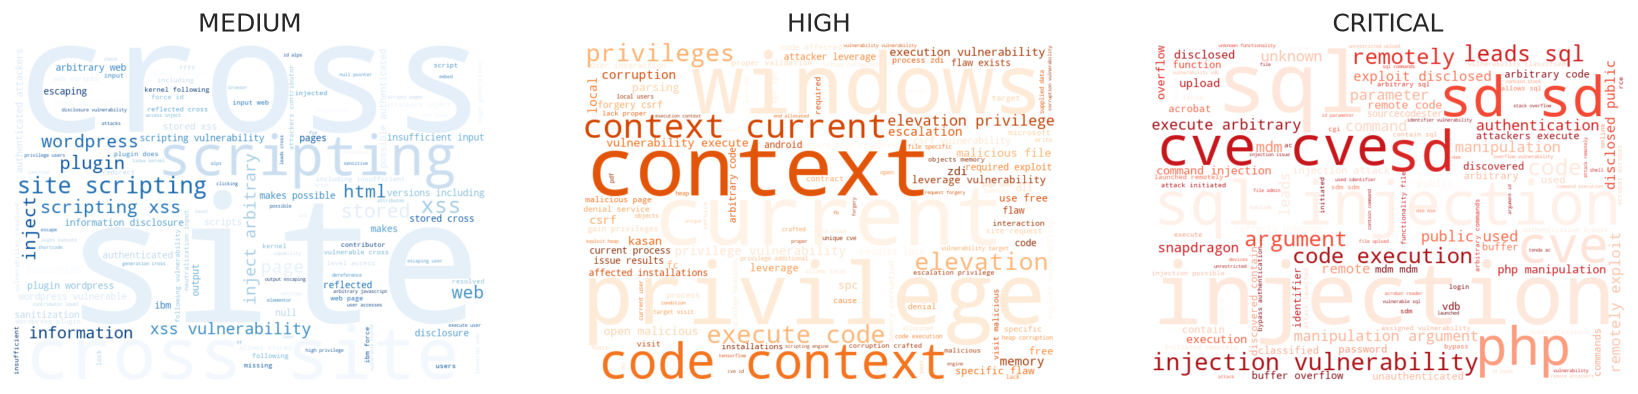

збережено assets/07-wordclouds.png
П'ятнадцять найхарактерніших слів/біграм кожного класу:
               MEDIUM                     HIGH                 CRITICAL
0                site                privilege                injection
1               cross                  windows                      sql
2          cross site                  current            sql injection
3           scripting                  context                       sd
4      site scripting             code context                    sd sd
5                 xss          context current                  cve cve
6              stored             execute code                      php
7              plugin                elevation                      cve
8       scripting xss               privileges  injection vulnerability
9                page      elevation privilege                leads sql
10                web  privilege vulnerability                     code
11               html                    loca

In [18]:
cv = CountVectorizer(ngram_range=(1, 2), min_df=5)
counts = cv.fit_transform(cve["clean"])
vocab = np.array(cv.get_feature_names_out())

top_raw = {}
for cls in CLASSES:
    freq = np.asarray(counts[(cve["label"] == cls).to_numpy()].sum(axis=0)).ravel()
    top_raw[cls] = vocab[np.argsort(-freq)[:10]]
print("Десять найчастіших слів у кожному класі:")
print(pd.DataFrame(top_raw).to_string())


def log_odds(counts, labels, cls, alpha0=1000.0):
    """Зважений log-odds ratio з інформативним апріорним розподілом Діріхле."""
    total = np.asarray(counts.sum(axis=0)).ravel().astype(float)
    a = alpha0 * total / total.sum()
    y_i = np.asarray(counts[labels == cls].sum(axis=0)).ravel()
    y_j = np.asarray(counts[labels != cls].sum(axis=0)).ravel()
    n_i, n_j, a0 = y_i.sum(), y_j.sum(), a.sum()
    delta = (np.log((y_i + a) / (n_i + a0 - y_i - a))
             - np.log((y_j + a) / (n_j + a0 - y_j - a)))
    var = 1 / (y_i + a) + 1 / (y_j + a)
    return delta / np.sqrt(var)


labels_arr = cve["label"].to_numpy()
distinct = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cls, cmap in zip(axes, CLASSES, ("Blues", "Oranges", "Reds")):
    z = log_odds(counts, labels_arr, cls)
    order = np.argsort(-z)[:120]
    weights = {vocab[i]: float(z[i]) for i in order if z[i] > 0}
    distinct[cls] = list(weights)[:15]
    wc = WordCloud(width=700, height=500, background_color="white", colormap=cmap,
                   random_state=RANDOM_STATE, prefer_horizontal=0.9
                   ).generate_from_frequencies(weights)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(cls, fontsize=14)
    ax.axis("off")
save(fig, "07-wordclouds.png")

print("П'ятнадцять найхарактерніших слів/біграм кожного класу:")
print(pd.DataFrame(distinct).to_string())

Хмари характерних слів напрочуд точно відтворюють логіку самої формули CVSS:

- **MEDIUM** — міжсайтовий скриптинг (*cross site scripting*, *xss*,
  *stored*, *wordpress*, *plugin*). XSS потребує дії користувача й зачіпає
  здебільшого браузер жертви, тож типова оцінка — 6.1.
- **HIGH** — підвищення привілеїв і локальні атаки (*privilege*, *elevation*,
  *local*, *windows*, *memory corruption*, *execute code in the context of the
  current user*). Атака потребує локального доступу або дії користувача, що
  знижує оцінку з критичної до високої.
- **CRITICAL** — віддалене виконання коду без автентифікації (*sql
  injection*, *code execution*, *remotely*, *php*). Мережевий вектор, без
  привілеїв і без дії користувача — саме ця комбінація дає 9.8.

Тобто класифікатор фактично вчиться вгадувати з тексту **базові метрики
CVSS** — вектор атаки, потрібні привілеї, взаємодію з користувачем. Два
застереження. *sd* — це назви процесорів Qualcomm Snapdragon (SD 400, SD 800) у
бюлетенях Android: слово характерне для класу, але через одного виробника, а не
через тип вразливості. Схоже й з *manipulation argument* — це шаблон VulDB, тож
частина сигналу відображає, **хто** писав опис.

### 3.4. Векторизація та класифікація

In [19]:
t_train, t_test, yt_train, yt_test = train_test_split(
    cve["clean"], cve["label"], test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=cve["label"])

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9, sublinear_tf=True)
T_train = tfidf.fit_transform(t_train)
T_test = tfidf.transform(t_test)
print(f"Train {T_train.shape[0]}, test {T_test.shape[0]}; словник TF-IDF: {T_train.shape[1]} ознак")
print(f"Базова лінія (класи збалансовані): {1 / len(CLASSES):.4f}")

text_models = {
    "Logistic Regression": LogisticRegression(C=4.0, max_iter=2000),
    "Linear SVM": LinearSVC(C=0.5),
    "Complement Naive Bayes": ComplementNB(alpha=0.3),
}
text_rows, text_pred = [], {}
for name, model in text_models.items():
    t0 = time.perf_counter()
    model.fit(T_train, yt_train)
    fit_s = time.perf_counter() - t0
    pred = model.predict(T_test)
    text_pred[name] = pred
    text_rows.append({"модель": name, "accuracy": accuracy_score(yt_test, pred),
                      "f1_macro": f1_score(yt_test, pred, average="macro"),
                      "час навчання, с": fit_s})
text_res = pd.DataFrame(text_rows).sort_values("f1_macro", ascending=False)
text_res.round(4).to_csv(DATA / "text-results.csv", index=False)
print(text_res.round(4).to_string(index=False))

Train 33750, test 11250; словник TF-IDF: 47957 ознак
Базова лінія (класи збалансовані): 0.3333


                модель  accuracy  f1_macro  час навчання, с
            Linear SVM    0.7035    0.7009           0.5970
   Logistic Regression    0.7021    0.7008          28.0320
Complement Naive Bayes    0.6493    0.6449           0.0652


Лінійні моделі на TF-IDF дають F1-macro близько 0.70 при базовій лінії 0.333.
Linear SVM і логістична регресія практично рівні (різниця — у четвертому
знаку), але SVM навчається в десятки разів швидше. Complement Naive Bayes
відстає на 0.06: припущення про незалежність слів для таких коротких і
шаблонних описів надто грубе.

Найкраща модель: Linear SVM

              precision    recall  f1-score   support

      MEDIUM     0.7471    0.7485    0.7478      3750
        HIGH     0.6449    0.5749    0.6079      3750
    CRITICAL     0.7111    0.7869    0.7471      3750

    accuracy                         0.7035     11250
   macro avg     0.7011    0.7035    0.7009     11250
weighted avg     0.7011    0.7035    0.7009     11250

Помилок усього: 3336; між сусідніми рівнями: 2781, MEDIUM <-> CRITICAL: 555


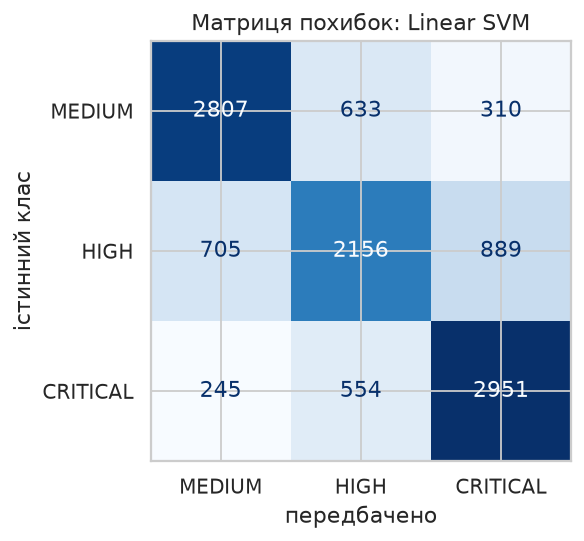

збережено assets/08-text-confusion.png


In [20]:
best_text = text_res.iloc[0]["модель"]
pred = text_pred[best_text]
print(f"Найкраща модель: {best_text}\n")
print(classification_report(yt_test, pred, labels=CLASSES, digits=4))

cm = confusion_matrix(yt_test, pred, labels=CLASSES)
adjacent = cm[0, 1] + cm[1, 0] + cm[1, 2] + cm[2, 1]
far = cm[0, 2] + cm[2, 0]
print(f"Помилок усього: {cm.sum() - np.trace(cm)}; між сусідніми рівнями: {adjacent}, "
      f"MEDIUM <-> CRITICAL: {far}")

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues",
                                                        colorbar=False, values_format="d")
ax.set_title(f"Матриця похибок: {best_text}")
ax.set_xlabel("передбачено"); ax.set_ylabel("істинний клас")
save(fig, "08-text-confusion.png")

Найгірше розпізнається клас HIGH (F1 = 0.61): він лежить **між** двома іншими,
тож помиляються з ним в обидва боки. Головне ж видно з матриці похибок: із
3 336 помилок 2 781 (83 %) — між **сусідніми** рівнями, і лише 555 — між MEDIUM і
CRITICAL. Модель майже не плутає «легку» вразливість із критичною; вона
помиляється на межах, де й експерти розходяться на один бал. Для задачі, де
мітка — порогове розбиття неперервної оцінки 0–10, це очікувана і навіть
здорова картина.

In [21]:
lr = text_models["Logistic Regression"]
feat = np.array(tfidf.get_feature_names_out())
coef_top = {cls: feat[np.argsort(-lr.coef_[i])[:12]] for i, cls in enumerate(lr.classes_)}
print("Ознаки з найбільшою вагою в логістичній регресії:")
print(pd.DataFrame(coef_top)[CLASSES].to_string())

Ознаки з найбільшою вагою в логістичній регресії:
                 MEDIUM                     HIGH            CRITICAL
0                   xss                xss issue           injection
1         authenticated         allows reflected     unauthenticated
2           leads cross                     csrf  unspecified impact
3   privilege execution            authenticated           execution
4                 local     privilege additional      authentication
5              physical            users execute            possibly
6     local information         local escalation                 sql
7        site scripting            reflected xss                 rce
8                 cross                      dll     deserialization
9              adjacent         event management             execute
10             disclose           impact crafted            password
11             redirect  privilege vulnerability      code execution


Ваги логістичної регресії підтверджують ту саму логіку: *unauthenticated*,
*rce*, *deserialization*, *code execution* тягнуть до CRITICAL; *xss*,
*authenticated*, *physical*, *local*, *adjacent* — до MEDIUM (атаки, що
потребують автентифікації, фізичного чи сусіднього доступу, отримують нижчі
оцінки). Слова *physical*, *adjacent*, *local* — це буквально значення метрики
«вектор атаки» у CVSS.

## Висновки

1. **PCA** на цьому датасеті стискає ознаки лише вдвічі (32 з 60 для 99 %
   дисперсії) і не пришвидшує навчання. Удавана катастрофа на кількох
   компонентах здебільшого пояснюється гіперпараметрами, підібраними для
   повного простору: після їх переналаштування SVM на 32 компонентах дає ту
   саму якість, що й без PCA.
2. **t-SNE** розділяє класи значно краще, ніж PCA, бо зберігає локальне
   сусідство, а не дисперсію, яку тут створюють викиди. Він також сам
   виокремлює кластер із 829 акаунтів без ERC20-даних — артефакт,
   знайдений у лабораторній № 1.
3. **K-Means** на стандартизованих важкохвостих ознаках вироджується (два
   викиди проти решти) і водночас дає оманливо високий silhouette. Після
   логарифмування кластери змістовні, але відповідають **рівню активності**
   акаунта, а не класу (ARI = −0.069). При більшому k з'являються підгрупи з
   частками шахраїв від 0.7 % до 64.8 % — корисні для аналізу ризику, хоч і не
   відтворюють міток.
4. **Класифікація текстів** CVE за критичністю дає F1-macro 0.70 при базовій
   лінії 0.33; 83 % помилок — між сусідніми рівнями. Характерні слова класів
   відтворюють логіку формули CVSS (вектор атаки, привілеї, взаємодія з
   користувачем). Перед навчанням довелося прибрати три витоки мітки:
   змішування версій CVSS, описи з процитованою оцінкою та оцінки VulDB.

In [22]:
print("Файли результатів:")
for f in sorted(DATA.glob("*.csv")):
    print("  ", f)
print("Рисунки:")
for f in sorted(ASSETS.glob("*.png")):
    print("  ", f)

Файли результатів:
   data/cve-filtering.csv
   data/ethereum-fraud.csv
   data/kmeans-k-log.csv
   data/kmeans-k.csv
   data/pca-comparison.csv
   data/pca-svm-tuned.csv
   data/text-results.csv
Рисунки:
   assets/01-pca-variance.png
   assets/02-pca-comparison.png
   assets/03-tsne.png
   assets/04-kmeans-k.png
   assets/05-kmeans-k-log.png
   assets/06-kmeans-clusters.png
   assets/07-wordclouds.png
   assets/08-text-confusion.png
